# Calculate Quaternions

In [ ]:
import pandas as pd
import numpy as np
from ahrs.filters import Madgwick
import time

import pandas as pd
import numpy as np
from ahrs.filters import Madgwick
import time

def generate_quaternion_dataset_fixed(input_file, output_file):
    print("Chargement des données brutes...")
    df = pd.read_csv(input_file)
    prefixes = ['ankleL', 'ankleR', 'back']
    fs = 60.0
    madgwick = Madgwick(frequency=fs, beta=0.041)
    

    sensor_cols = []
    for pref in prefixes:
        sensor_cols.extend([f'{pref}_acc_x', f'{pref}_acc_y', f'{pref}_acc_z', 
                            f'{pref}_gyro_x', f'{pref}_gyro_y', f'{pref}_gyro_z'])
        
    print(f"Lignes avant nettoyage : {len(df)}")
    df = df.dropna(subset=sensor_cols).reset_index(drop=True)
    print(f"Lignes après nettoyage : {len(df)}")
    
    final_df_list = []
    subjects = df['subjectID'].unique()
    
    for sub in subjects:
        print(f"Traitement des quaternions pour le Sujet {sub}...")
        sub_df = df[df['subjectID'] == sub].copy().reset_index(drop=True)
        
        for pref in prefixes:
            acc = sub_df[[f'{pref}_acc_x', f'{pref}_acc_y', f'{pref}_acc_z']].values
            gyr = np.deg2rad(sub_df[[f'{pref}_gyro_x', f'{pref}_gyro_y', f'{pref}_gyro_z']].values)
            
            # Réinitialisation parfaite au début du patient
            Q = np.zeros((len(sub_df), 4))
            Q[0] = [1.0, 0.0, 0.0, 0.0] 
            
            # Boucle Madgwick
            for t in range(1, len(sub_df)):
                Q[t] = madgwick.updateIMU(Q[t-1], gyr=gyr[t], acc=acc[t])
                
            sub_df[f'{pref}_q0'] = Q[:, 0]
            sub_df[f'{pref}_q1'] = Q[:, 1]
            sub_df[f'{pref}_q2'] = Q[:, 2]
            sub_df[f'{pref}_q3'] = Q[:, 3]
            
        final_df_list.append(sub_df)
        
    # 3. SAUVEGARDE FINALE
    print("Fusion des patients et sauvegarde...")
    final_df = pd.concat(final_df_list, axis=0).reset_index(drop=True)
    
    q_cols = [f'{pref}_q{i}' for pref in prefixes for i in range(4)]
    cols_to_keep = ['subjectID', 'taskID', 'activity', 'fog'] + q_cols
    
    final_df[cols_to_keep].to_csv(output_file, index=False)
    print(f"SUCCÈS ! Fichier sauvegardé sous : {output_file}")

# --- Exécution ---
generate_quaternion_dataset_fixed('sensor_data.csv', 'sensor_data_quaternions.csv')

Chargement des données brutes...
Lignes avant nettoyage : 329027
Lignes après nettoyage : 291782
Traitement des quaternions pour le Sujet 1...
Traitement des quaternions pour le Sujet 2...
Traitement des quaternions pour le Sujet 3...
Traitement des quaternions pour le Sujet 4...
Traitement des quaternions pour le Sujet 5...
Traitement des quaternions pour le Sujet 6...
Traitement des quaternions pour le Sujet 7...
Traitement des quaternions pour le Sujet 8...
Traitement des quaternions pour le Sujet 10...
Traitement des quaternions pour le Sujet 11...
Traitement des quaternions pour le Sujet 12...
Traitement des quaternions pour le Sujet 13...
Traitement des quaternions pour le Sujet 14...
Traitement des quaternions pour le Sujet 15...
Traitement des quaternions pour le Sujet 16...
Traitement des quaternions pour le Sujet 17...
Traitement des quaternions pour le Sujet 18...
Traitement des quaternions pour le Sujet 19...
Traitement des quaternions pour le Sujet 20...
Traitement des qua

# New training - baseline model with quaternions

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, GlobalAveragePooling1D, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
def segment_12ch_q_data(df, subject_list, w=2, o=0.75, Fs=60):
    windowSize = int(w * Fs)
    overlap = int(o * w * Fs)
    slide = windowSize - overlap
    
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    X_list = []
    y_list = []
    
    for sub_id in subject_list:
        sub_df = df[df['subjectID'] == sub_id].reset_index(drop=True)
        

        total_windows = (len(sub_df) - windowSize) // slide + 1
        
        if total_windows <= 0:
            continue
            
        sub_X = np.zeros((total_windows, windowSize, 12), dtype=np.float32)
        sub_y = np.zeros((total_windows,), dtype=np.float32)
        
        data_vals = sub_df[cols].values
        label_vals = sub_df['fog'].values
        
        for i in range(total_windows):
            start = i * slide
            end = start + windowSize
            
            sub_X[i] = data_vals[start:end]
            
            sub_y[i] = pd.Series(label_vals[start:end]).mode()[0]
            
        X_list.append(sub_X)
        y_list.append(sub_y)
        
    X_final = np.vstack(X_list)
    y_final = np.concatenate(y_list)
    
    return X_final, y_final

In [18]:
print(f"Shape de X_train : {X_train.shape}")
print(f"Shape de y_train : {y_train.shape}")

Shape de X_train : (2622, 120, 12)
Shape de y_train : (2622,)


In [ ]:
def build_12ch_quaternion_model(window_size=120, num_channels=12):
    model = Sequential([
        Input(shape=(window_size, num_channels)), 
        

        Conv1D(32, kernel_size=9, activation='relu', padding='causal', kernel_regularizer=l2(0.001)),
        Conv1D(32, kernel_size=9, activation='relu', padding='causal', kernel_regularizer=l2(0.001)),
        MaxPooling1D(pool_size=4),
        Dropout(0.4),
        
        # Third conv block 
        Conv1D(48, kernel_size=7, activation='relu', padding='causal', kernel_regularizer=l2(0.001)),
        MaxPooling1D(pool_size=3),
        Dropout(0.4),
        
        # Fourth conv block
        Conv1D(48, kernel_size=5, activation='relu', padding='causal', kernel_regularizer=l2(0.001)),
        
        # Global Average Pooling instead of Flatten
        GlobalAveragePooling1D(),
        
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, 
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc_roc')], jit_compile=False)
    return model

In [ ]:
import pandas as pd
import numpy as np
if __name__ == '__main__':
    print("Loading Quaternion Dataset...")
    # Assure-toi d'utiliser le fichier généré avec les quaternions
    df = pd.read_csv('sensor_data_quaternions.csv') 
    
    q_cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    df = df.dropna(subset=q_cols)   
    
    train_ids = list(range(1, 12))
    val_ids   = list(range(12, 17))
    test_ids  = list(range(17, 23))
    
    print(f"Segmenting: Train({len(train_ids)} subs), Val({len(val_ids)} subs), Test({len(test_ids)} subs)")
    X_train, y_train = segment_12ch_q_data(df, train_ids)
    X_val, y_val     = segment_12ch_q_data(df, val_ids)
    X_test, y_test   = segment_12ch_q_data(df, test_ids)

    counts = np.bincount(y_train.astype(int))    
    weight_for_0 = (1 / counts[0]) * (len(y_train) / 2.0)
    weight_for_1 = (1 / counts[1]) * (len(y_train) / 2.0)
    class_weights = {0: weight_for_0, 1: weight_for_1}

    print("Building and Training 12-Channel Quaternion Model...")
    model = build_12ch_quaternion_model()
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )

    print("\n--- FINAL TEST RESULTS ON UNSEEN SUBJECTS ---")
    results = model.evaluate(X_test, y_test)
    print(f"Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}, Test AUC: {results[2]:.4f}")

    model.save('fog_fusion_model_12ch_quaternion.h5')
    print("Model saved as fog_fusion_model_12ch_quaternion.h5")

Loading Quaternion Dataset...
Segmenting: Train(11 subs), Val(5 subs), Test(6 subs)
Building and Training 12-Channel Quaternion Model...
Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5469 - auc_roc: 0.6650 - loss: 0.8484 - val_accuracy: 0.6805 - val_auc_roc: 0.4777 - val_loss: 0.7834
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7542 - auc_roc: 0.8118 - loss: 0.7140 - val_accuracy: 0.8864 - val_auc_roc: 0.5099 - val_loss: 0.5967
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8191 - auc_roc: 0.8540 - loss: 0.6438 - val_accuracy: 0.9061 - val_auc_roc: 0.5215 - val_loss: 0.5772
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8354 - auc_roc: 0.8785 - loss: 0.6030 - val_accuracy: 0.9026 - val_auc_roc: 0.5402 - val_loss: 0.5497
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8498 - auc_roc: 0.8977 - loss: 0.5682 - val_accuracy: 0.9046 - val_auc_roc: 0.5440 - val_loss: 0.5291
Epoch 6/100
92/92 ━━━━━

Test Loss: 0.7253, Test Accuracy: 0.7761, Test AUC: 0.5377
Model saved as fog_fusion_model_12ch_quaternion.h5


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

print("Chargement des données du Sujet 19...")
df = pd.read_csv('sensor_data_quaternions.csv')
sub19_df = df[df['subjectID'] == 19].copy().reset_index(drop=True)

split_idx = int(len(sub19_df) * 0.3)
df_train_ft = sub19_df.iloc[:split_idx].copy()
df_test_ft  = sub19_df.iloc[split_idx:].copy()

print(f"Lignes pour l'entraînement : {len(df_train_ft)}")
print(f"Lignes pour le test : {len(df_test_ft)}")

# 3. Segmentation (On réutilise ta super fonction sécurisée !)
X_ft_train, y_ft_train = segment_12ch_q_data(df_train_ft, [19])
X_ft_test, y_ft_test   = segment_12ch_q_data(df_test_ft, [19])

print(f"Fenêtres de Fine-Tuning : {X_ft_train.shape}")
print(f"Fenêtres de Test : {X_ft_test.shape}")

# 4. Calcul des poids de classe pour le Sujet 19
counts = np.bincount(y_ft_train.astype(int))
if len(counts) == 2 and counts[1] > 0:
    weight_0 = (1 / counts[0]) * (len(y_ft_train) / 2.0)
    weight_1 = (1 / counts[1]) * (len(y_ft_train) / 2.0)
    class_weights = {0: weight_0, 1: weight_1}
else:
    class_weights = {0: 1.0, 1: 1.0} # Sécurité si pas de gel dans les premiers 30%

print("\nChargement du modèle de base (12 canaux)...")
model = load_model('fog_fusion_model_12ch_quaternion.h5', compile=False)

optimizer = Adam(learning_rate=1e-5)
model.compile(loss='binary_crossentropy', 
              optimizer=optimizer, 
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc_roc')],
              jit_compile=False) # On garde la sécurité pour ton serveur !

print("\n--- PERFORMANCE AVANT FINE-TUNING ---")
res_before = model.evaluate(X_ft_test, y_ft_test, verbose=0)
print(f"Test AUC: {res_before[2]:.4f}")

# 8. Entraînement (Fine-Tuning)
print("\n--- DÉMARRAGE DU FINE-TUNING ---")
history = model.fit(
    X_ft_train, y_ft_train,
    epochs=15,          # Pas besoin de beaucoup d'époques
    batch_size=32,      # Petit batch size pour s'adapter finement
    class_weight=class_weights,
    verbose=1
)

# 9. Évaluation APRÈS le Fine-Tuning
print("\n--- PERFORMANCE APRÈS FINE-TUNING SUR LES 70% RESTANTS ---")
res_after = model.evaluate(X_ft_test, y_ft_test, verbose=1)
print(f"Nouvel AUC de Test: {res_after[2]:.4f} (Avant: {res_before[2]:.4f})")


Chargement des données du Sujet 19...
Lignes pour l'entraînement : 6578
Lignes pour le test : 15350
Fenêtres de Fine-Tuning : (216, 120, 12)
Fenêtres de Test : (508, 120, 12)

Chargement du modèle de base (12 canaux)...

--- PERFORMANCE AVANT FINE-TUNING ---
Test AUC: 0.4260

--- DÉMARRAGE DU FINE-TUNING ---
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4074 - auc_roc: 0.7009 - loss: 1.3504
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4074 - auc_roc: 0.7300 - loss: 1.3202
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4167 - auc_roc: 0.6826 - loss: 1.3142
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4074 - auc_roc: 0.7381 - loss: 1.2280
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4120 - auc_roc: 0.6906 - loss: 1.2178
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4259 - auc_roc: 0.6968 - loss: 1.1925
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4259 - auc_roc: 0.710

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

def analyze_errors_12ch_q(df_path, y_true, y_pred, test_ids, w=2, o=0.75, Fs=60):
    print("Reconstruction des activités pour l'analyse...")
    df = pd.read_csv(df_path)
    
    q_cols = [f'{pref}_q{i}' for pref in ['ankleL', 'ankleR', 'back'] for i in range(4)]
    df = df.dropna(subset=q_cols).reset_index(drop=True)
    
    windowSize = int(w * Fs)
    overlap = int(o * w * Fs)
    slide = windowSize - overlap
    
    activities_list = []
    
    for sub_id in test_ids:
        sub_df = df[df['subjectID'] == sub_id].reset_index(drop=True)
        total_windows = (len(sub_df) - windowSize) // slide + 1
        
        if total_windows <= 0:
            continue
            
        act_vals = sub_df['activity'].values
        
        for i in range(total_windows):
            start = i * slide
            end = start + windowSize
            # On prend l'activité majoritaire de la fenêtre
            act = pd.Series(act_vals[start:end]).mode()[0]
            activities_list.append(act)
            
    if len(activities_list) != len(y_pred):
        raise ValueError(f"Erreur de dimension : {len(activities_list)} activités vs {len(y_pred)} prédictions.")
        
    res_df = pd.DataFrame({
        'Activity': activities_list,
        'True_Label': y_true.flatten(),
        'Prediction': y_pred.flatten()
    })
    
    results = []
    for act in res_df['Activity'].unique():
        act_df = res_df[res_df['Activity'] == act]
        
        total = len(act_df)
        tp = len(act_df[(act_df['True_Label'] == 1) & (act_df['Prediction'] == 1)])
        fp = len(act_df[(act_df['True_Label'] == 0) & (act_df['Prediction'] == 1)])
        tn = len(act_df[(act_df['True_Label'] == 0) & (act_df['Prediction'] == 0)])
        fn = len(act_df[(act_df['True_Label'] == 1) & (act_df['Prediction'] == 0)])
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        results.append({
            'Activity': act,
            'Total Windows': total,
            'False Positives': int(fp),
            'True Positives': int(tp),
            'Precision': round(precision, 2),
            'Specificity': round(specificity, 2),
            'Recall': round(recall, 2)
        })
        
    report_df = pd.DataFrame(results).sort_values(by='False Positives', ascending=False)
    
    print("\n" + "="*85)
    print("   RAPPORT DE PERFORMANCE PAR ACTIVITÉ (MODÈLE DE BASE - QUATERNIONS 12 CANAUX)")
    print("="*85)
    print(report_df.to_string(index=False))
    
    return report_df

df_all = pd.read_csv('sensor_data_quaternions.csv')
test_ids = [17, 18, 19, 20, 21, 22]
X_test, y_test = segment_12ch_q_data(df_all, test_ids)

print("Chargement du modèle...")
model_base = load_model('fog_fusion_model_12ch_quaternion.h5', compile=False)

print("Prédiction sur le set de Test...")
y_pred_probs = model_base.predict(X_test, batch_size=64)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

report = analyze_errors_12ch_q('sensor_data_quaternions.csv', y_test, y_pred_classes, test_ids)

Chargement du modèle...
Prédiction sur le set de Test...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Reconstruction des activités pour l'analyse...

   RAPPORT DE PERFORMANCE PAR ACTIVITÉ (MODÈLE DE BASE - QUATERNIONS 12 CANAUX)
 Activity  Total Windows  False Positives  True Positives  Precision  Specificity  Recall
        1            801               17               0       0.00         0.98    0.00
        6            187                3               6       0.67         0.97    0.07
        7            449                0               5       1.00         1.00    0.02
        5             18                0               0       0.00         1.00    0.00
        2             37                0               0       0.00         1.00    0.00
        4             12                0               0       0.00         1.00    0.00
        3            278                0               0       0.00         1.00    0.00


When confronted with spatial orientations (e.g., facing South vs. North) that differed from the training set, the network's learned features failed. To minimize its loss, the model resorted to systematically predicting the majority class (normal walking).

Despite exhibiting excellent training performance (Train AUC > 0.96), the model demonstrated an inability to generalize to unseen patients (Test AUC ~ 0.53) and even failed during personalized Fine-Tuning attempts (Test AUC ~ 0.36). The per-activity analysis revealed a catastrophic Recall rate, close to 0% during complex movements (e.g., turning).
Physical explanation: The network suffered from spatial overfitting. Because absolute quaternions encode orientation relative to magnetic North, the model memorized the specific geographic directions in which the training patients were walking. Consequently, as soon as a test patient walked in a different direction, the network's learned spatial representations failed, rendering it blind to the FoG movements.

# Relative quaternions

In [ ]:
def segment_12ch_q_data_relative(df, subject_list, w=2, o=0.75, Fs=60):
    windowSize = int(w * Fs)
    overlap = int(o * w * Fs)
    slide = windowSize - overlap
    
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',s
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    X_list, y_list = [], []
    
    for sub_id in subject_list:
        sub_df = df[df['subjectID'] == sub_id].reset_index(drop=True)
        total_windows = (len(sub_df) - windowSize) // slide + 1
        
        if total_windows <= 0:
            continue
            
        sub_X = np.zeros((total_windows, windowSize, 12), dtype=np.float32)
        sub_y = np.zeros((total_windows,), dtype=np.float32)
        
        data_vals = sub_df[cols].values
        label_vals = sub_df['fog'].values
        
        for i in range(total_windows):
            start = i * slide
            end = start + windowSize
            
            # --- THE ONLY CHANGE IS HERE ---
            # We subtract the first row of the window from the entire window
            window_brute = data_vals[start:end]
            sub_X[i] = window_brute - window_brute[0] 
            
            sub_y[i] = pd.Series(label_vals[start:end]).mode()[0]
            
        X_list.append(sub_X)
        y_list.append(sub_y)
        
    return np.vstack(X_list), np.concatenate(y_list)

In [8]:
import pandas as pd
import numpy as np
df = pd.read_csv('sensor_data_quaternions.csv') 
    
q_cols = [
    'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
    'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
    'back_q0', 'back_q1', 'back_q2', 'back_q3'
]
df = df.dropna(subset=q_cols) 
train_ids = list(range(1, 12))
val_ids   = list(range(12, 17))
test_ids  = list(range(17, 23))
print("Generating Relative Quaternion Data...")
X_train, y_train = segment_12ch_q_data_relative(df, train_ids)
X_val, y_val     = segment_12ch_q_data_relative(df, val_ids)
X_test, y_test   = segment_12ch_q_data_relative(df, test_ids)

# Recalculate your class weights based on the new y_train
counts = np.bincount(y_train.astype(int))
weight_for_0 = (1 / counts[0]) * (len(y_train) / 2.0)
weight_for_1 = (1 / counts[1]) * (len(y_train) / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}

Generating Relative Quaternion Data...


In [16]:
model_relative = build_12ch_quaternion_model() 

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 2. Train it from scratch
print("\n--- TRAINING NEW RELATIVE QUATERNION MODEL ---")
history = model_relative.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# 3. Save it with a new name so you don't overwrite the old one
model_relative.save('fog_model_12ch_relative_quat.h5')

# 4. Final Evaluation
results = model_relative.evaluate(X_test, y_test)
print(f"New Test AUC: {results[2]:.4f}")


--- TRAINING NEW RELATIVE QUATERNION MODEL ---
Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7567 - auc_roc: 0.6584 - loss: 0.8577 - val_accuracy: 0.8097 - val_auc_roc: 0.4794 - val_loss: 0.7711
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7446 - auc_roc: 0.7681 - loss: 0.7775 - val_accuracy: 0.7320 - val_auc_roc: 0.6520 - val_loss: 0.5944
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7535 - auc_roc: 0.8195 - loss: 0.7001 - val_accuracy: 0.7208 - val_auc_roc: 0.7229 - val_loss: 0.5057
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7531 - auc_roc: 0.8299 - loss: 0.6510 - val_accuracy: 0.7234 - val_auc_roc: 0.7546 - val_loss: 0.4879
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7475 - auc_roc: 0.8409 - loss: 0.6066 - val_accuracy: 0.7173 - val_auc_roc: 0.8040 - val_loss: 0.4977
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7436 - auc_roc: 0.8457 - loss: 0.5716 - val_accurac

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7935 - auc_roc: 0.8949 - loss: 0.4649
New Test AUC: 0.8949


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

ACTIVITY_MAP = {
    1: "Walking",
    2: "Sit",
    3: "Stand",
    4: "Sit-to-Stand",
    5: "Stand-to-Sit",
    6: "Turn Right",
    7: "Turn Left"
}

def analyze_errors_relative(df_path, y_true, y_pred, test_ids, w=2, o=0.75, Fs=60):
    print("Reconstructing activities for analysis...")
    df = pd.read_csv(df_path)
    
    q_cols = [f'{pref}_q{i}' for pref in ['ankleL', 'ankleR', 'back'] for i in range(4)]
    df = df.dropna(subset=q_cols).reset_index(drop=True)
    
    windowSize = int(w * Fs)
    overlap = int(o * w * Fs)
    slide = windowSize - overlap
    
    activities_list = []
    
    for sub_id in test_ids:
        sub_df = df[df['subjectID'] == sub_id].reset_index(drop=True)
        total_windows = (len(sub_df) - windowSize) // slide + 1
        
        if total_windows <= 0: continue
            
        act_vals = sub_df['activity'].values
        for i in range(total_windows):
            start = i * slide
            end = start + windowSize
            act = pd.Series(act_vals[start:end]).mode()[0]
            activities_list.append(act)
            
    if len(activities_list) != len(y_pred):
        raise ValueError("Dimension error: Mismatch between activities and predictions.")
        
    res_df = pd.DataFrame({
        'Activity_Code': activities_list,
        'True_Label': y_true.flatten(),
        'Prediction': y_pred.flatten()
    })
    
    res_df['Activity_Name'] = res_df['Activity_Code'].map(ACTIVITY_MAP)
    
    results = []
    for act_code in res_df['Activity_Code'].unique():
        act_name = ACTIVITY_MAP.get(act_code, f"Unknown ({act_code})")
        act_df = res_df[res_df['Activity_Code'] == act_code]
        
        total = len(act_df)
        tp = len(act_df[(act_df['True_Label'] == 1) & (act_df['Prediction'] == 1)])
        fp = len(act_df[(act_df['True_Label'] == 0) & (act_df['Prediction'] == 1)])
        tn = len(act_df[(act_df['True_Label'] == 0) & (act_df['Prediction'] == 0)])
        fn = len(act_df[(act_df['True_Label'] == 1) & (act_df['Prediction'] == 0)])
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        results.append({
            'Activity': act_name,
            'Total Windows': total,
            'False Positives': int(fp),
            'True Positives': int(tp),
            'Precision': round(precision, 2),
            'Specificity': round(specificity, 2),
            'Recall': round(recall, 2)
        })
        
    report_df = pd.DataFrame(results).sort_values(by='False Positives', ascending=False)
    
    print("\n" + "="*90)
    print("   PERFORMANCE REPORT BY ACTIVITY (RELATIVE QUATERNIONS MODEL)")
    print("="*90)
    print(report_df.to_string(index=False))
    
    return report_df


print("Loading the new Relative Quaternion model...")
model_relative = load_model('fog_model_12ch_relative_quat.h5', compile=False)

print("Making predictions on the Test set...")
y_pred_probs_rel = model_relative.predict(X_test, batch_size=64)
y_pred_classes_rel = (y_pred_probs_rel > 0.5).astype(int)

test_ids = [17, 18, 19, 20, 21, 22]
report = analyze_errors_relative('sensor_data_quaternions.csv', y_test, y_pred_classes_rel, test_ids)

Loading the new Relative Quaternion model...
Making predictions on the Test set...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Reconstructing activities for analysis...

   PERFORMANCE REPORT BY ACTIVITY (RELATIVE QUATERNIONS MODEL)
    Activity  Total Windows  False Positives  True Positives  Precision  Specificity  Recall
       Stand            278              208               3       0.01         0.24    1.00
   Turn Left            449               28             201       0.88         0.86    0.82
  Turn Right            187               20              74       0.79         0.81    0.90
     Walking            801               15              32       0.68         0.98    0.54
Stand-to-Sit             18                0               0       0.00         1.00    0.00
Sit-to-Stand             12                0               0       0.00         1.00    0.00
         Sit             37                0               0       0.00         1.00    0.00


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# The dictionary you provided
ACTIVITY_MAP = {
    1: "Walking",
    2: "Sit",
    3: "Stand",
    4: "Sit-to-Stand",
    5: "Stand-to-Sit",
    6: "Turn Right",
    7: "Turn Left"
}

def analyze_errors_relative(df_path, y_true, y_pred, test_ids, w=2, o=0.75, Fs=60):
    print("Reconstructing activities for analysis...")
    df = pd.read_csv(df_path)
    
    q_cols = [f'{pref}_q{i}' for pref in ['ankleL', 'ankleR', 'back'] for i in range(4)]
    df = df.dropna(subset=q_cols).reset_index(drop=True)
    
    windowSize = int(w * Fs)
    overlap = int(o * w * Fs)
    slide = windowSize - overlap
    
    activities_list = []
    
    for sub_id in test_ids:
        sub_df = df[df['subjectID'] == sub_id].reset_index(drop=True)
        total_windows = (len(sub_df) - windowSize) // slide + 1
        
        if total_windows <= 0: continue
            
        act_vals = sub_df['activity'].values
        for i in range(total_windows):
            start = i * slide
            end = start + windowSize
            act = pd.Series(act_vals[start:end]).mode()[0]
            activities_list.append(act)
            
    if len(activities_list) != len(y_pred):
        raise ValueError("Dimension error: Mismatch between activities and predictions.")
        
    res_df = pd.DataFrame({
        'Activity_Code': activities_list,
        'True_Label': y_true.flatten(),
        'Prediction': y_pred.flatten()
    })
    
    # Map the activity codes to their names
    res_df['Activity_Name'] = res_df['Activity_Code'].map(ACTIVITY_MAP)
    
    results = []
    for act_code in res_df['Activity_Code'].unique():
        act_name = ACTIVITY_MAP.get(act_code, f"Unknown ({act_code})")
        act_df = res_df[res_df['Activity_Code'] == act_code]
        
        total = len(act_df)
        tp = len(act_df[(act_df['True_Label'] == 1) & (act_df['Prediction'] == 1)])
        fp = len(act_df[(act_df['True_Label'] == 0) & (act_df['Prediction'] == 1)])
        tn = len(act_df[(act_df['True_Label'] == 0) & (act_df['Prediction'] == 0)])
        fn = len(act_df[(act_df['True_Label'] == 1) & (act_df['Prediction'] == 0)])
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        results.append({
            'Activity': act_name,
            'Total Windows': total,
            'False Positives': int(fp),
            'True Positives': int(tp),
            'Precision': round(precision, 2),
            'Specificity': round(specificity, 2),
            'Recall': round(recall, 2)
        })
        
    report_df = pd.DataFrame(results).sort_values(by='False Positives', ascending=False)
    
    print("\n" + "="*90)
    print("   PERFORMANCE REPORT BY ACTIVITY (RELATIVE QUATERNIONS MODEL)")
    print("="*90)
    print(report_df.to_string(index=False))
    
    return report_df


print("Loading the new Relative Quaternion model...")
model_relative = load_model('fog_model_12ch_relative_quat.h5', compile=False)

print("Making predictions on the Test set...")
y_pred_probs_rel = model_relative.predict(X_test, batch_size=64)
y_pred_classes_rel = (y_pred_probs_rel > 0.7).astype(int)

test_ids = [17, 18, 19, 20, 21, 22]
report = analyze_errors_relative('sensor_data_quaternions.csv', y_test, y_pred_classes_rel, test_ids)

Loading the new Relative Quaternion model...
Making predictions on the Test set...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Reconstructing activities for analysis...

   PERFORMANCE REPORT BY ACTIVITY (RELATIVE QUATERNIONS MODEL)
    Activity  Total Windows  False Positives  True Positives  Precision  Specificity  Recall
       Stand            278               73               3       0.04         0.73    1.00
   Turn Left            449               29             183       0.86         0.86    0.75
  Turn Right            187               24              62       0.72         0.77    0.76
     Walking            801                8              13       0.62         0.99    0.22
Stand-to-Sit             18                0               0       0.00         1.00    0.00
Sit-to-Stand             12                0               0       0.00         1.00    0.00
         Sit             37                0               0       0.00         1.00    0.00


In [22]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

print(classification_report(y_test, y_pred_classes_rel, target_names=['No FoG', 'FoG']))

              precision    recall  f1-score   support

      No FoG       0.91      0.90      0.91      1392
         FoG       0.66      0.67      0.66       390

    accuracy                           0.85      1782
   macro avg       0.78      0.79      0.79      1782
weighted avg       0.85      0.85      0.85      1782



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


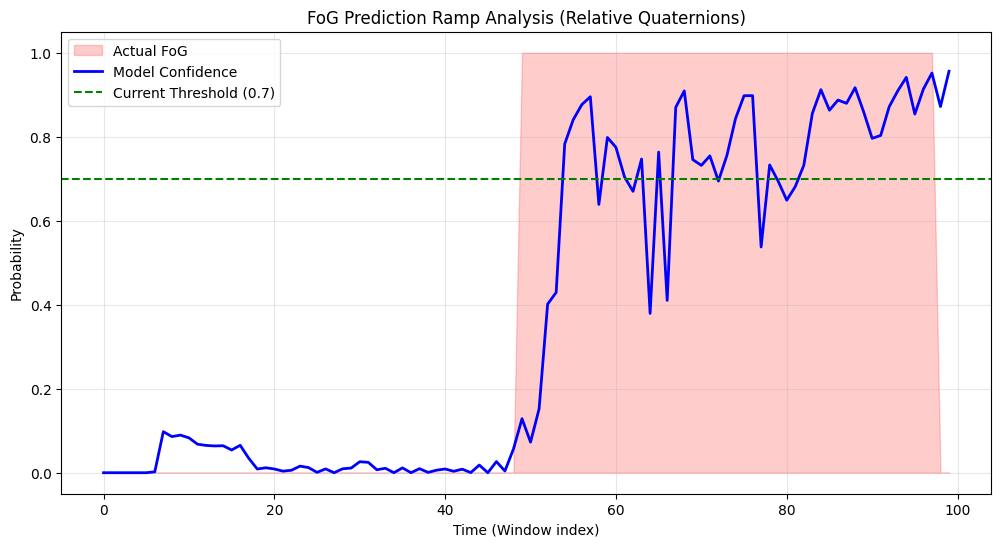

In [ ]:
import matplotlib.pyplot as plt

def plot_prediction_ramp(model, X_test, y_test, window_idx, search_range=50):
    """
    Plots the probability lead-up to a specific FoG event.
    window_idx: The index of a known FoG event in your test set.
    search_range: How many windows to look at before and after.
    """
    start_idx = max(0, window_idx - search_range)
    end_idx = min(len(X_test), window_idx + search_range)
    
    X_chunk = X_test[start_idx:end_idx]
    y_chunk = y_test[start_idx:end_idx]
    
    # Get raw probabilities (0.0 to 1.0)
    probs = model.predict(X_chunk).flatten()
    
    plt.figure(figsize=(12, 6))
    
    # Plot Ground Truth (Shaded Area)
    plt.fill_between(range(len(y_chunk)), y_chunk, color='red', alpha=0.2, label='Actual FoG')
    
    # Plot Model Probability (The "Ramp")
    plt.plot(range(len(probs)), probs, color='blue', linewidth=2, label='Model Confidence')
    
    # Add a threshold line (e.g., 0.7)
    plt.axhline(y=0.7, color='green', linestyle='--', label='Current Threshold (0.7)')
    
    plt.title(f"FoG Prediction Ramp Analysis (Relative Quaternions)")
    plt.xlabel("Time (Window index)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


first_fog_idx = np.where(y_test == 1)[0][1]

# Visualize the ramp for that event
plot_prediction_ramp(model_relative, X_test, y_test, window_idx=first_fog_idx)

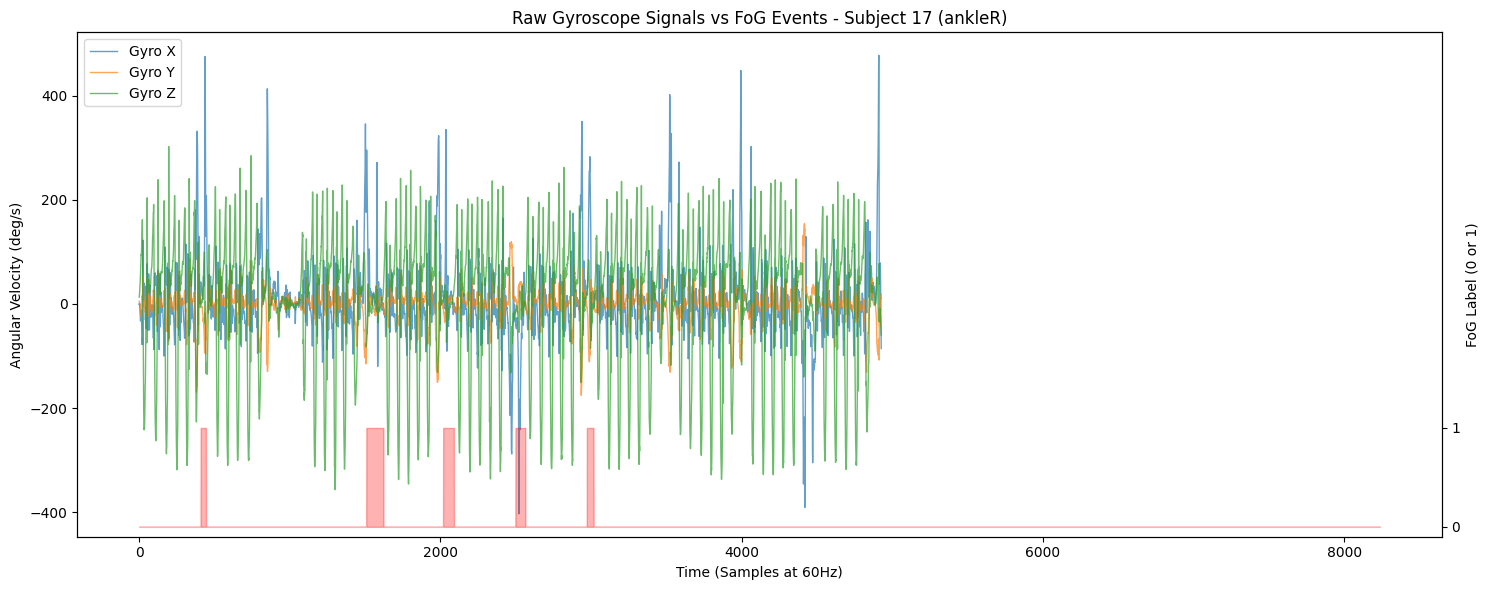

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_raw_signals_with_fog(df_path, subject_id, sensor_prefix='ankleR'):
    # 1. Load data
    df = pd.read_csv(df_path)
    
    # 2. Filter for one specific subject to keep the plot clean
    sub_df = df[df['subjectID'] == subject_id].reset_index()
    
    # 3. Create the plot
    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Plot Gyroscope axes on the left Y-axis
    ax1.plot(sub_df.index, sub_df[f'{sensor_prefix}_gyro_x'], label='Gyro X', alpha=0.7, linewidth=1)
    ax1.plot(sub_df.index, sub_df[f'{sensor_prefix}_gyro_y'], label='Gyro Y', alpha=0.7, linewidth=1)
    ax1.plot(sub_df.index, sub_df[f'{sensor_prefix}_gyro_z'], label='Gyro Z', alpha=0.7, linewidth=1)
    
    ax1.set_xlabel('Time (Samples at 60Hz)')
    ax1.set_ylabel('Angular Velocity (deg/s)')
    ax1.legend(loc='upper left')
    
    # 4. Create a second Y-axis for the FoG labels
    ax2 = ax1.twinx()
    # Fill the area where FoG == 1
    ax2.fill_between(sub_df.index, 0, sub_df['fog'], color='red', alpha=0.3, label='FoG Event')
    ax2.set_ylabel('FoG Label (0 or 1)')
    ax2.set_ylim(-0.1, 5) # Keep the red area at the bottom
    ax2.set_yticks([0, 1])
    
    plt.title(f"Raw Gyroscope Signals vs FoG Events - Subject {subject_id} ({sensor_prefix})")
    plt.tight_layout()
    plt.show()


plot_raw_signals_with_fog('sensor_data.csv', subject_id=17)